### 使用mmdeploy_runtime部署，无需安装torch
使用这个部署就不需要自己额外去写预处理和后处理代码部署了，全部打包带走
(天坑啊，尝试了python3.8，3.9.3.10，

只有python3.8！！！！！！！！
能够兼容直接使用mmdeploy部署，并且下载mmdeploy_runtime国内镜像只有华为云兼容，能够满足python3.8的环境可以尝试一下)

### 模型转换与生成pipline所需的文件

In [ ]:
# convert_mmseg.py
import os
import torch
from mmdeploy.apis import torch2onnx
from mmdeploy.backend.sdk import export_info

# 1. 填写自己的路径
config_path   = '/home/shenjunyu/projects/mmdetection/configs_seg/植物分割/大烟叶分割-deeplabv3+.py'
checkpoint    = '/data2/project/plant/3-模型备份/大烟叶分割/20250812_113057/deeplabv3plus_20250812_113057.pth'
test_img      = '/data2/project/plant/1-标注数据/植物分割/大烟叶/标注数据/1.bmp'
work_dir      = '大烟叶模型部署'
device        = 'cuda:0'

os.makedirs(work_dir, exist_ok=True)

# 2. 转换模型 -> end2end.onnxpip
torch2onnx(
    img=test_img,
    work_dir=work_dir,
    save_file='cigarette.onnx',
    deploy_cfg='/home/shenjunyu/projects/mmdeploy/configs/mmseg/segmentation_onnxruntime_dynamic.py',
    model_cfg=config_path,
    model_checkpoint=checkpoint,
    device=device
)

# 3. 生成 deploy.json / pipeline.json
from mmdeploy.backend.sdk.export_info import export2SDK   # 注意从 sdk.export_info 下引入

export2SDK(
    deploy_cfg='/home/shenjunyu/projects/mmdeploy/configs/mmseg/segmentation_onnxruntime_dynamic.py',
    model_cfg=config_path,
    work_dir=work_dir,
    pth=checkpoint,
    device = 'cpu'
)
print(f'转换完成，结果已保存到 {work_dir}')

: 

### 使用mmdeploy和torch查看部署结果

In [ ]:
from mmdeploy.apis.utils import build_task_processor
from mmdeploy.utils import get_input_shape, load_config
import torch

deploy_cfg = '/home/shenjunyu/projects/mmdeploy/configs/mmseg/segmentation_onnxruntime_dynamic.py'
model_cfg = '/home/shenjunyu/projects/mmdetection/configs_seg/植物分割/大烟叶分割-deeplabv3+.py'
device = 'cpu'
backend_model = ['/home/shenjunyu/projects/mmdetection/configs_seg/植物分割/大烟叶模型部署/end2end.onnx']
image = '/data2/project/plant/1-标注数据/植物分割/大烟叶/标注数据/1.bmp'

# read deploy_cfg and model_cfg
deploy_cfg, model_cfg = load_config(deploy_cfg, model_cfg)

# build task and backend model
task_processor = build_task_processor(model_cfg, deploy_cfg, device)
model = task_processor.build_backend_model(backend_model)

# process input image
input_shape = get_input_shape(deploy_cfg)



#推理
model_inputs, _ = task_processor.create_input(image, input_shape)
# do model inference
with torch.no_grad():
    result = model.test_step(model_inputs)

import matplotlib.pyplot as plt
import numpy as np
data = np.array(result[0].pred_sem_seg.data)
plt.imshow(data[0,:,:])

08/20 08:57:35 - mmengine - INFO - Successfully loaded onnxruntime custom ops from /home/shenjunyu/miniconda3/envs/mmtrain/lib/python3.11/site-packages/mmdeploy/lib/libmmdeploy_onnxruntime_ops.so


### 使用mmdeploy_runtime部署
环境仅仅需要安装mmdeploy_runtime，就可以跑模型了，C++也可以调用SDK包
不需要自己额外写预处理和后处理代码了

In [6]:
import cv2
import numpy as np
from mmdeploy_runtime import Segmentor

# 1. 读图（可用你自己的 LoadFileFromImage 代替）
img = cv2.imread('/data2/project/plant/1-标注数据/植物分割/大烟叶/标注数据/1.bmp')        # BGR HWC uint8
assert img is not None

# 2. 初始化 Segmentor（路径指到刚才拷过来的目录）
seg = Segmentor(model_path='/home/shenjunyu/projects/mmdetection/configs_seg/植物分割/大烟叶模型部署', device_name='cpu')  # GPU 写 cuda

# 3. 推理
mask = seg(img)            # 返回 HxW int64 的类别 id
print('mask shape:', mask.shape)

# # 4. 简单可视化
# palette = np.array([[0,0,0],[128,64,128],[70,70,70],...], dtype=np.uint8)  # 按 cityscapes 取
# color = palette[mask.astype(np.uint8)]
# blend = img * 0.5 + color * 0.5
# cv2.imwrite('vis.png', blend)

[2025-08-20 09:41:10.085] [mmdeploy] [info] [model.cpp:35] [DirectoryModel] Load model: "/home/shenjunyu/projects/mmdetection/configs_seg/植物分割/大烟叶模型部署"
mask shape: (8000, 4096)


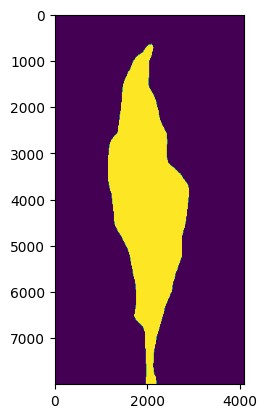

In [7]:
import matplotlib.pyplot as plt
plt.imshow(mask)